# Seasonal Agriculture Performance Analysis

**Major Project — VOIS AICTE (Batch 1, 2026-2027)**

## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed under different seasonal conditions.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

Students should independently explore the dataset, formulate relevant analytical questions, select suitable analytical techniques, and communicate findings based on evidence from the data.

## 2. Project Objectives

- Understand the structure and quality of the agricultural dataset.
- Clean and prepare the data for analysis.
- Explore seasonal patterns in the dataset.
- Perform descriptive and statistical analysis.
- Investigate relationships among relevant variables.
- Compare agricultural performance across seasons and other meaningful groups.
- Use appropriate univariate, bivariate and multivariate visualizations.
- Identify significant findings from the data.
- Develop evidence-based insights and recommendations.
- Document limitations and conclusions clearly.

## 3. Dataset Overview

The dataset contains 4,000 records of agricultural activity across 8 Indian states, 10 districts, 8 crop types and 3 seasons (Kharif, Rabi, Zaid). It includes 28 variables covering farm characteristics, environmental conditions, resource usage, and economic outcomes.

Before any analysis, it is important to understand the structure of the dataset — its size, column types, and general quality.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option('display.max_columns', None)

# Load dataset
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset (3).csv')

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [44]:
categorical_cols = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']

for col in categorical_cols:
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].unique())


State (8 unique values):
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District (10 unique values):
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop (8 unique values):
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season (3 unique values):
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method (4 unique values):
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


**Observations:**
- The dataset has 4,000 rows and 28 columns, with a mix of categorical (State, District, Crop, Season, Irrigation_Method) and numerical variables (environmental, resource, and economic indicators).
- `Season` has 3 categories — Kharif, Rabi, Zaid — which forms the primary basis for our seasonal comparisons.
- Some columns (Rainfall_mm, Soil_Moisture_pct, Yield_Tonnes_Ha) show fewer non-null entries than others, indicating missing values that will need to be addressed in the data cleaning stage.

## 4. Data Cleaning & Preparation

Before performing any analysis, the dataset needs to be checked for duplicate records, missing values, and outliers. Clean data ensures that the patterns and insights we derive are reliable.

In [45]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate records: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicate records found.")

Number of duplicate records: 0
No duplicate records found.


In [46]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]
missing_summary

,Missing Count,Missing %
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [47]:
# Rainfall, Soil_Moisture, and Yield have missing values (~1-1.2% each)
# Since these are continuous variables that vary by season, we fill missing values
# with the median of their respective Season group (more accurate than a global median)

for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:\n", df.isnull().sum().sum())

Remaining missing values:
 0


### Outlier Investigation

Two variables stood out during initial exploration:
- **Yield_Tonnes_Ha**: median ~1.7 but maximum over 100, suggesting possible extreme values or data entry errors.
- **Profit_INR**: ranges from a large negative loss to a large positive profit, indicating high variability across farms.

We investigate both before deciding whether to cap, remove, or retain these values.

In [48]:
Q1 = df['Yield_Tonnes_Ha'].quantile(0.25)
Q3 = df['Yield_Tonnes_Ha'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_yield = df[(df['Yield_Tonnes_Ha'] < lower_bound) | (df['Yield_Tonnes_Ha'] > upper_bound)]
print(f"Yield outliers (IQR method): {len(outliers_yield)} records ({len(outliers_yield)/len(df)*100:.1f}%)")
print(f"Bounds: lower={lower_bound:.2f}, upper={upper_bound:.2f}")

outliers_yield[['State', 'Crop', 'Season', 'Yield_Tonnes_Ha']].sort_values('Yield_Tonnes_Ha', ascending=False).head(10)

Yield outliers (IQR method): 302 records (7.5%)
Bounds: lower=-1.62, upper=5.50


,State,Crop,Season,Yield_Tonnes_Ha
1715,Gujarat,Sugarcane,Kharif,101.44
3423,Andhra Pradesh,Sugarcane,Kharif,95.79
3525,Andhra Pradesh,Sugarcane,Rabi,93.13
1464,Gujarat,Sugarcane,Kharif,91.98
3523,Karnataka,Sugarcane,Kharif,91.46
2782,Gujarat,Sugarcane,Rabi,91.32
644,Andhra Pradesh,Sugarcane,Kharif,89.34
2847,Telangana,Sugarcane,Kharif,87.76
357,Punjab,Sugarcane,Rabi,84.75
1178,Karnataka,Sugarcane,Kharif,83.79


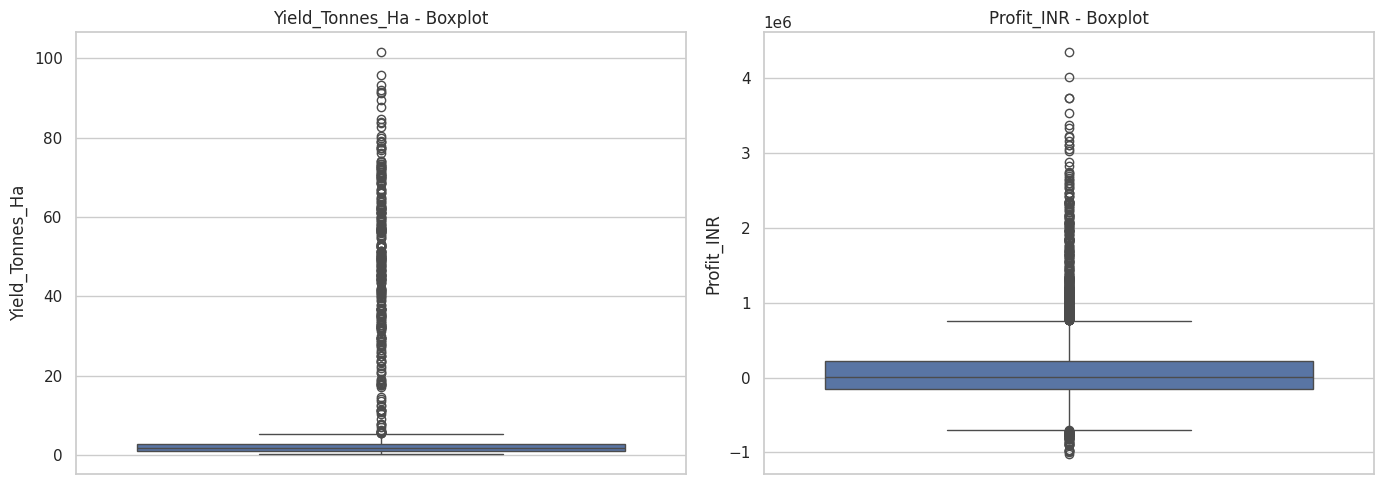

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=df['Yield_Tonnes_Ha'], ax=axes[0])
axes[0].set_title('Yield_Tonnes_Ha - Boxplot')

sns.boxplot(y=df['Profit_INR'], ax=axes[1])
axes[1].set_title('Profit_INR - Boxplot')
plt.tight_layout()
plt.show()

### Decision on Outliers

The IQR method flags a portion of records in `Yield_Tonnes_Ha` and `Profit_INR` as statistical outliers. However, these are not treated as data errors — extreme yield and profit values can genuinely occur due to differences in crop type, irrigation method, and seasonal conditions.

**Decision:** Outliers are retained in the dataset but will be examined specifically during the seasonal comparison and correlation analysis, since they may represent important patterns rather than noise.

## 5. Descriptive & Statistical Analysis

This section summarizes the central tendency, spread, and distribution of key numerical variables in the dataset.

In [50]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.714313,288.427366,80.000,370.425,581.0000,836.12500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.504525,6.696998,8.000,21.700,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [51]:
key_metrics = ['Yield_Tonnes_Ha', 'Rainfall_mm',  'Profit_INR']
df.groupby('Season')[key_metrics].agg(['mean', 'median', 'std']).round(2)

Yield_Tonnes_Ha               Rainfall_mm                 Profit_INR  \
                  mean median    std        mean  median     std       mean   
Season                                                                        
Kharif            5.63   1.95  14.39      852.11  854.75  181.57  178914.65   
Rabi              5.04   1.66  12.75      435.94  430.30  174.69   87689.47   
Zaid              4.64   1.45  11.27      299.12  283.30  152.56  -24804.82   

                            
         median        std  
Season                      
Kharif  38808.0  611549.78  
Rabi    -3187.0  489901.25  
Zaid   -62144.0  436356.75

**Observations:**
- *(Fill in after running: Which season has the highest average yield? Which has the highest variability in profit? Note anything surprising.)*

## 6. Univariate Analysis

Univariate analysis examines individual variables in isolation to understand their distribution before looking at relationships between them.

/tmp/ipykernel_7171/1095549299.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Season', order=df['Season'].value_counts().index, palette='Set2')


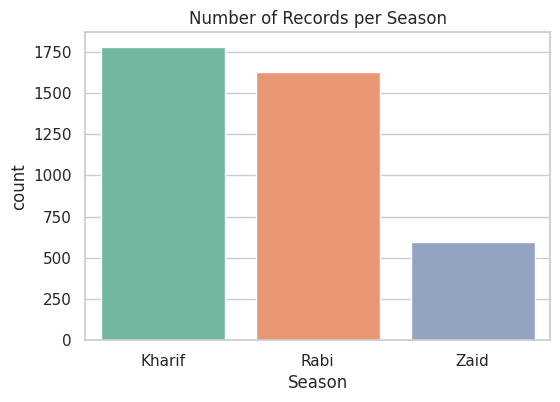

In [52]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Season', order=df['Season'].value_counts().index, palette='Set2')
plt.title('Number of Records per Season')
plt.show()

/tmp/ipykernel_7171/313708229.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Crop', order=df['Crop'].value_counts().index, palette='Set3')


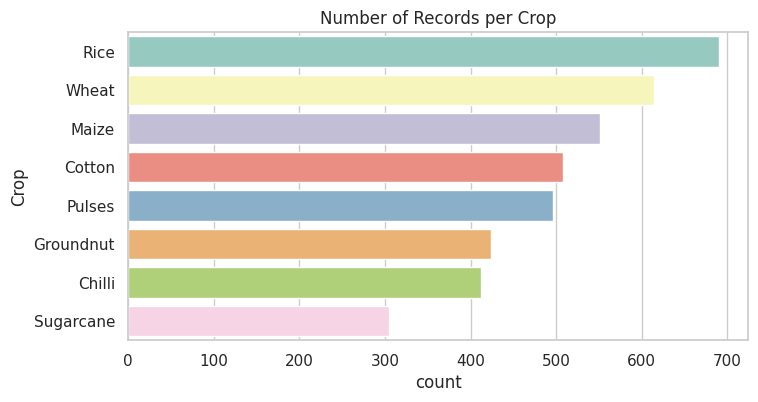

In [53]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, y='Crop', order=df['Crop'].value_counts().index, palette='Set3')
plt.title('Number of Records per Crop')
plt.show()

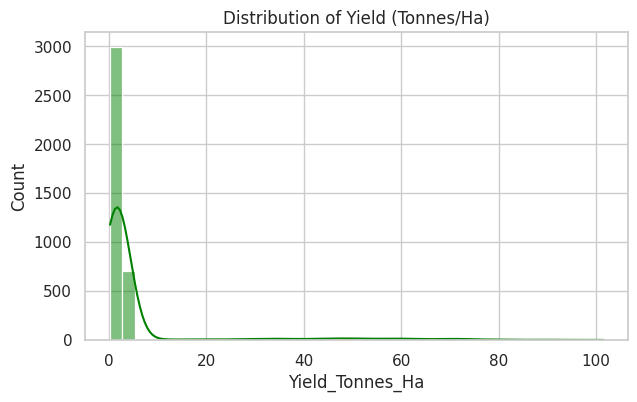

In [54]:
plt.figure(figsize=(7,4))
sns.histplot(df['Yield_Tonnes_Ha'], bins=40, kde=True, color='green')
plt.title('Distribution of Yield (Tonnes/Ha)')
plt.show()

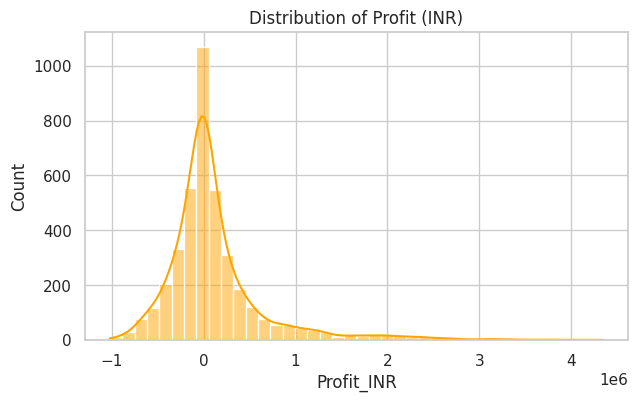

In [55]:
plt.figure(figsize=(7,4))
sns.histplot(df['Profit_INR'], bins=40, kde=True, color='orange')
plt.title('Distribution of Profit (INR)')
plt.show()

**Observations:**
- *(Fill in after running: Are records evenly spread across seasons? Is one crop dominant? Is Yield right-skewed? Is Profit roughly symmetric or skewed toward losses/gains?)*

## 7. Bivariate Analysis

Bivariate analysis explores the relationship between two variables at a time — particularly how key outcomes vary across seasons and other categorical factors.

/tmp/ipykernel_7171/1166297232.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='Set2')


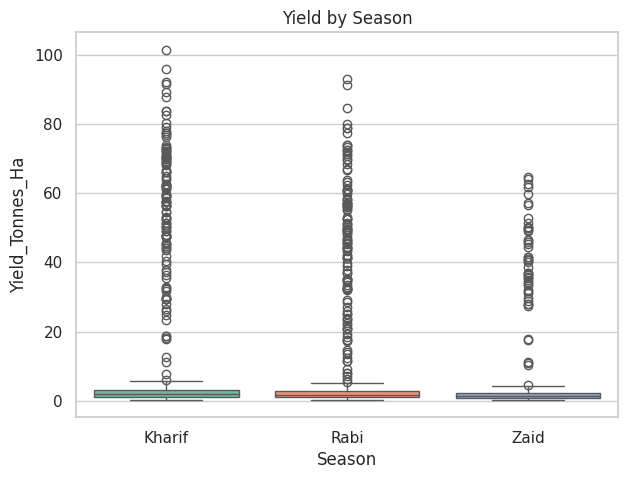

In [56]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='Set2')
plt.title('Yield by Season')
plt.show()

/tmp/ipykernel_7171/3083344524.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Profit_INR', palette='Set2')


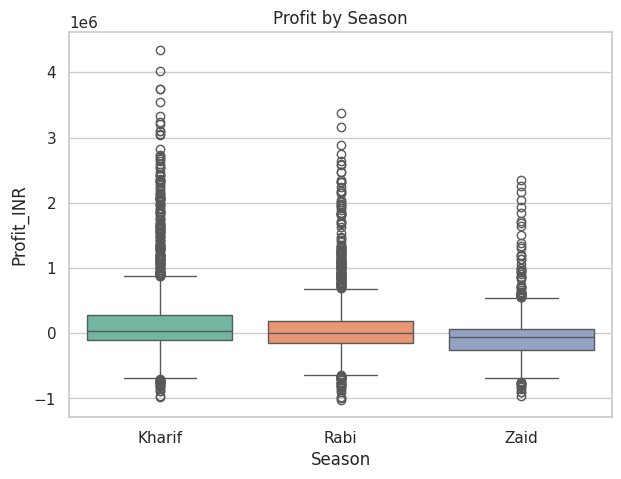

In [57]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Season', y='Profit_INR', palette='Set2')
plt.title('Profit by Season')
plt.show()

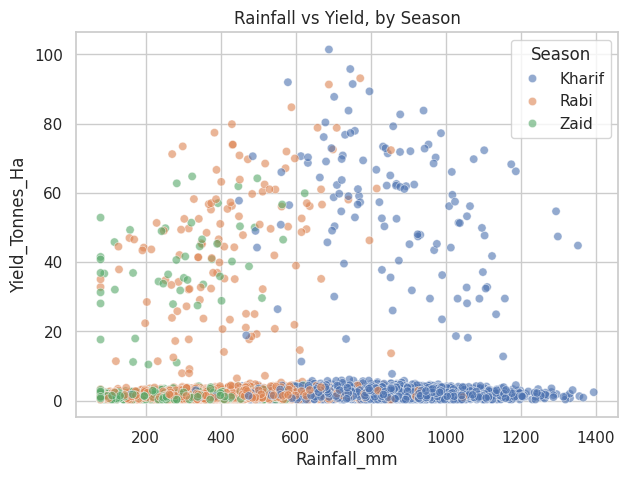

In [58]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', alpha=0.6)
plt.title('Rainfall vs Yield, by Season')
plt.show()

/tmp/ipykernel_7171/1519924918.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Irrigation_Method', y='Yield_Tonnes_Ha', palette='Set3')


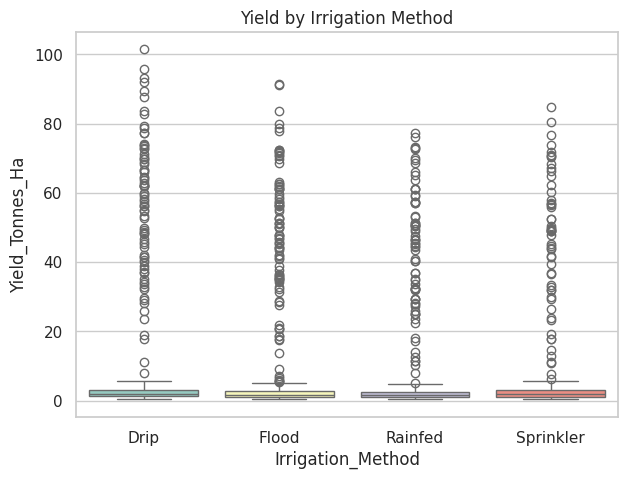

In [59]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Irrigation_Method', y='Yield_Tonnes_Ha', palette='Set3')
plt.title('Yield by Irrigation Method')
plt.show()

/tmp/ipykernel_7171/1959310381.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crop_profit.values, y=crop_profit.index, palette='coolwarm')


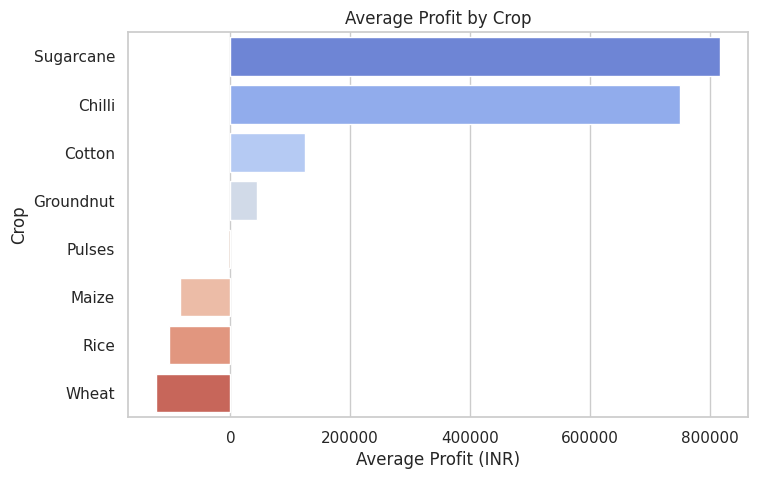

In [60]:
plt.figure(figsize=(8,5))
crop_profit = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)
sns.barplot(x=crop_profit.values, y=crop_profit.index, palette='coolwarm')
plt.title('Average Profit by Crop')
plt.xlabel('Average Profit (INR)')
plt.show()

**Observations:**
- *(Fill in after running: Which season has the highest median yield/profit? Does rainfall show a clear positive relationship with yield? Which irrigation method performs best? Which crop is most/least profitable?)*

## 8. Multivariate Analysis

Multivariate analysis brings together three or more variables simultaneously to uncover more complex, combined patterns than univariate or bivariate views can show.

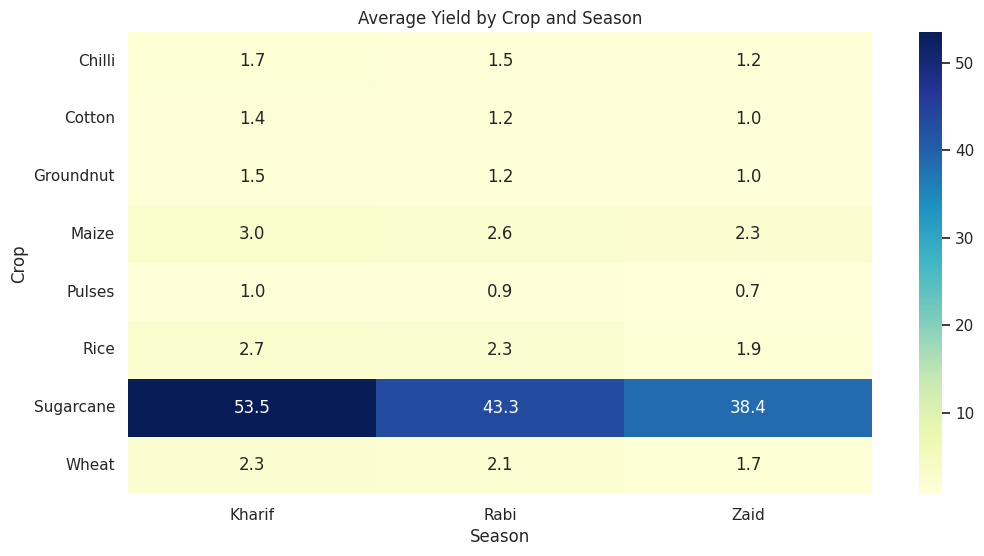

In [61]:
plt.figure(figsize=(12,6))
pivot1 = df.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season', aggfunc='mean')
sns.heatmap(pivot1, annot=True, fmt=".1f", cmap='YlGnBu')
plt.title('Average Yield by Crop and Season')
plt.show()

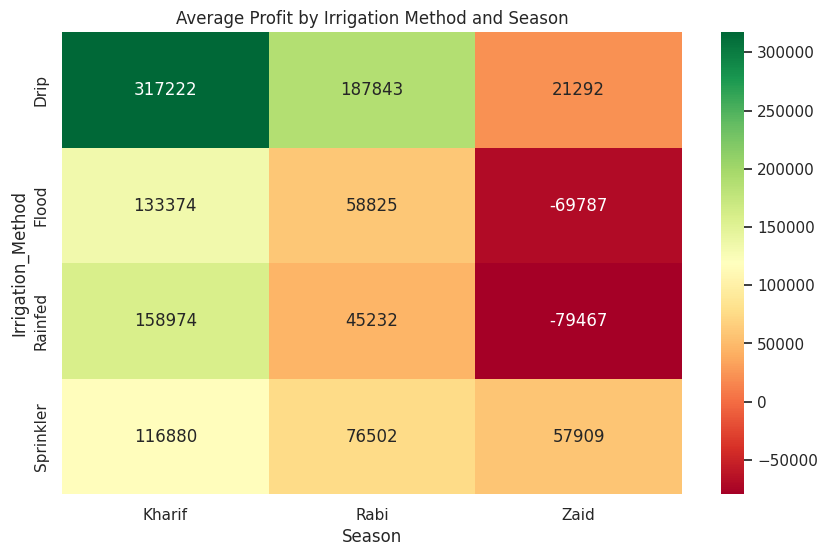

In [62]:
plt.figure(figsize=(10,6))
pivot2 = df.pivot_table(values='Profit_INR', index='Irrigation_Method', columns='Season', aggfunc='mean')
sns.heatmap(pivot2, annot=True, fmt=".0f", cmap='RdYlGn')
plt.title('Average Profit by Irrigation Method and Season')
plt.show()

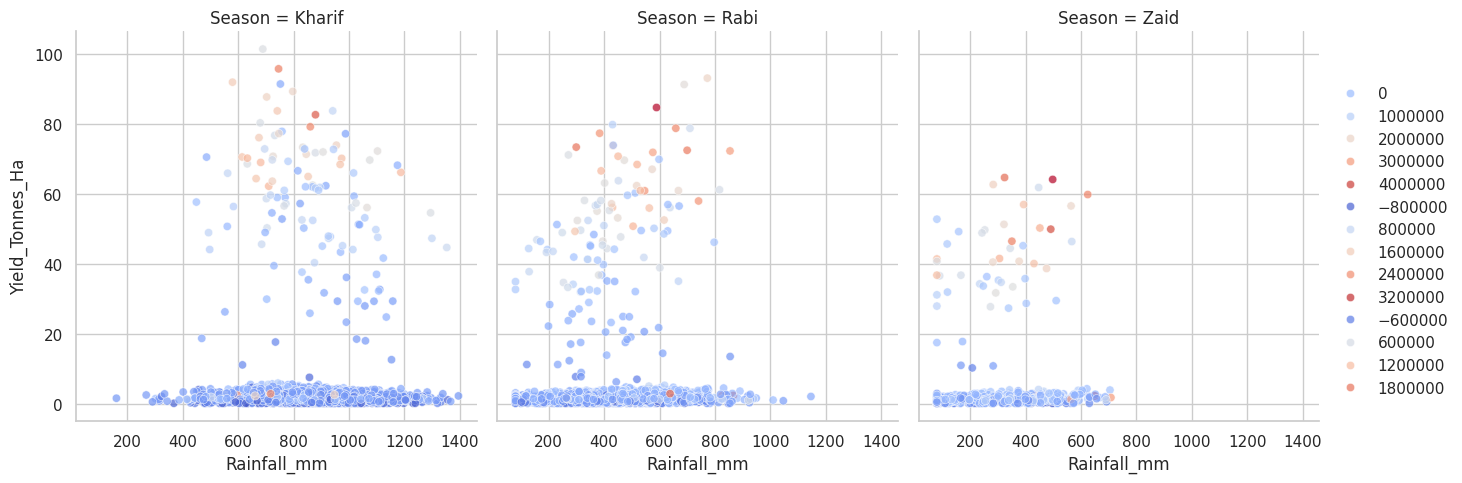

In [63]:
g = sns.FacetGrid(df, col='Season', height=5, aspect=0.9)
g.map_dataframe(sns.scatterplot, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Profit_INR', palette='coolwarm', alpha=0.7)
g.add_legend()
plt.show()


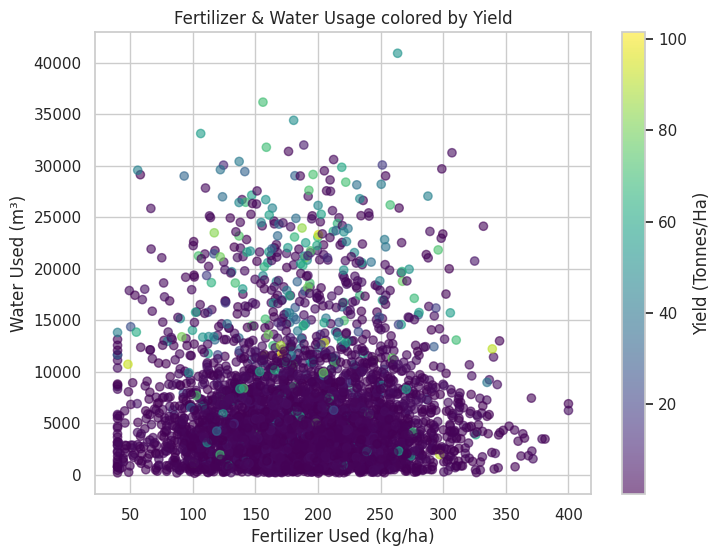

In [64]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(df['Fertilizer_kg_ha'], df['Water_Used_m3'],
                       c=df['Yield_Tonnes_Ha'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Yield (Tonnes/Ha)')
plt.xlabel('Fertilizer Used (kg/ha)')
plt.ylabel('Water Used (m³)')
plt.title('Fertilizer & Water Usage colored by Yield')
plt.show()

In [65]:
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [66]:
print([c for c in df.columns if 'ater' in c])

['Water_Used_m3', 'Water_Efficiency_t_per_1000m3']


**Observations:**
- *(Fill in after running: Which crop-season combination gives highest yield? Which irrigation-season combination is most profitable? Does high fertilizer + high water usage consistently mean high yield, or diminishing returns?)*

## 9. Correlation Analysis

Correlation analysis measures the strength and direction of linear relationships between numerical variables. This helps identify which factors are most closely associated with yield and profit.

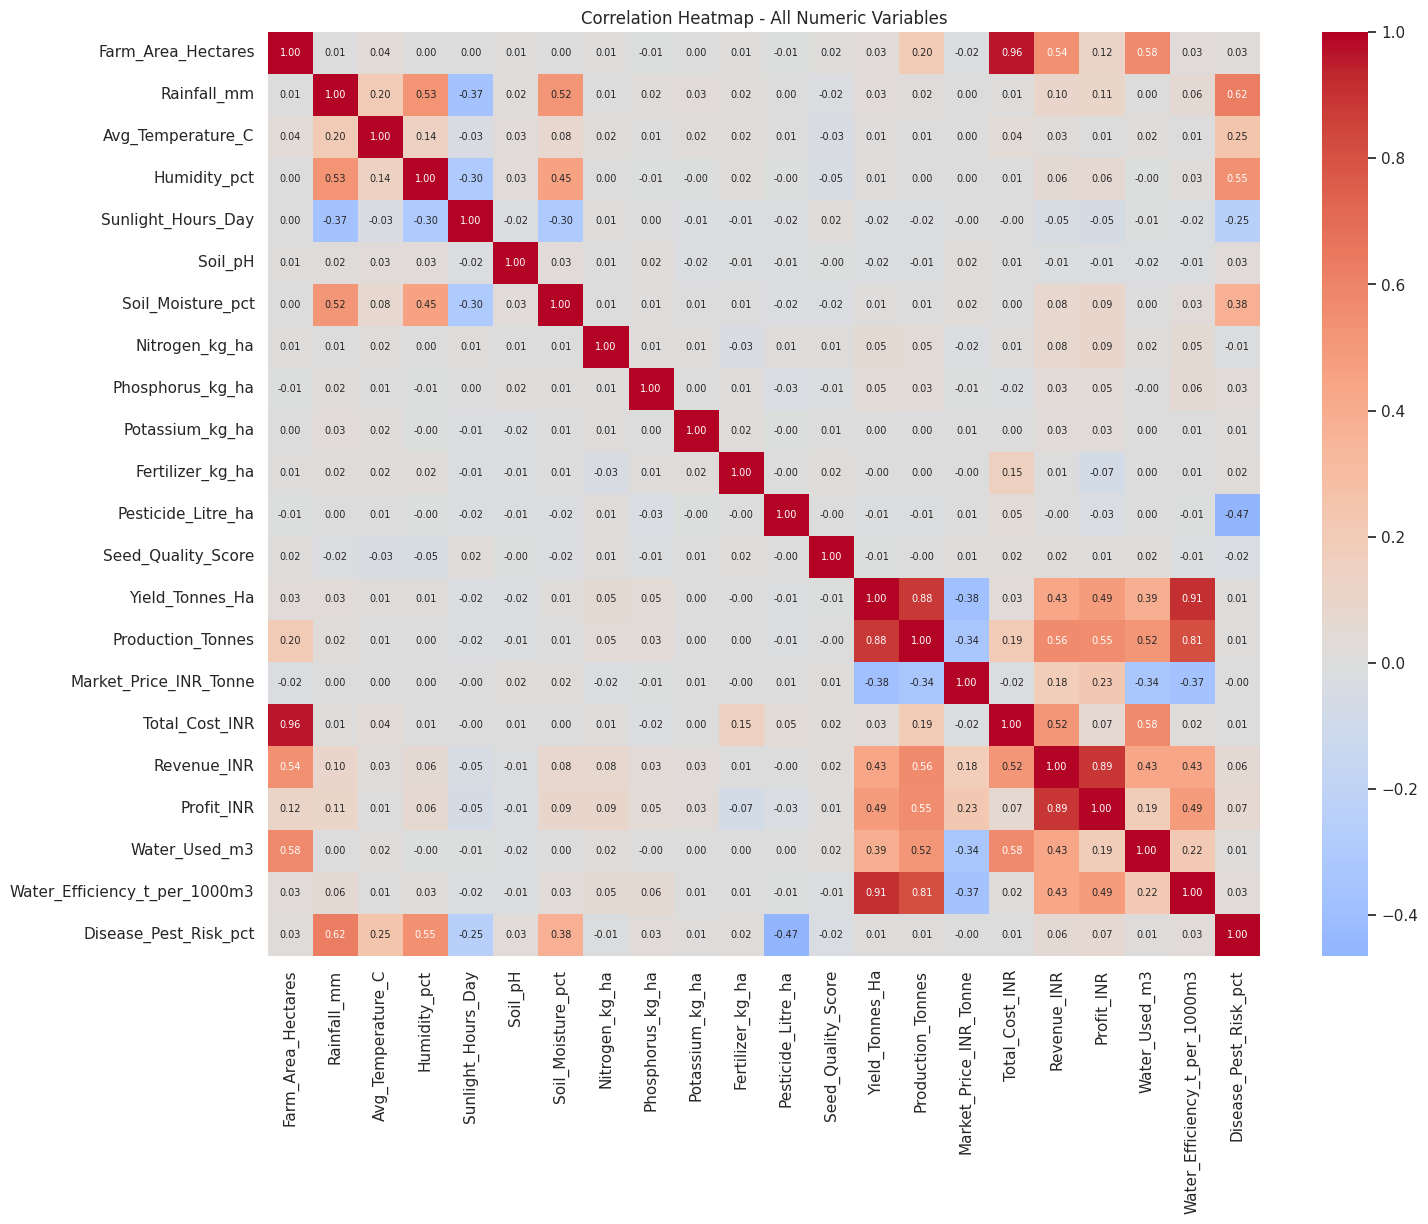

In [67]:
plt.figure(figsize=(16,12))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, annot_kws={"size":7})
plt.title('Correlation Heatmap - All Numeric Variables')
plt.show()

In [68]:
target_vars = ['Yield_Tonnes_Ha', 'Profit_INR']

for target in target_vars:
    print(f"\nTop correlations with {target}:")
    print(corr[target].sort_values(ascending=False).drop(target).head(8))


Top correlations with Yield_Tonnes_Ha:
Water_Efficiency_t_per_1000m3    0.912561
Production_Tonnes                0.882804
Profit_INR                       0.488459
Revenue_INR                      0.432139
Water_Used_m3                    0.386298
Nitrogen_kg_ha                   0.053167
Phosphorus_kg_ha                 0.047974
Total_Cost_INR                   0.030606
Name: Yield_Tonnes_Ha, dtype: float64

Top correlations with Profit_INR:
Revenue_INR                      0.887331
Production_Tonnes                0.554172
Water_Efficiency_t_per_1000m3    0.489487
Yield_Tonnes_Ha                  0.488459
Market_Price_INR_Tonne           0.225119
Water_Used_m3                    0.190278
Farm_Area_Hectares               0.115241
Rainfall_mm                      0.106117
Name: Profit_INR, dtype: float64


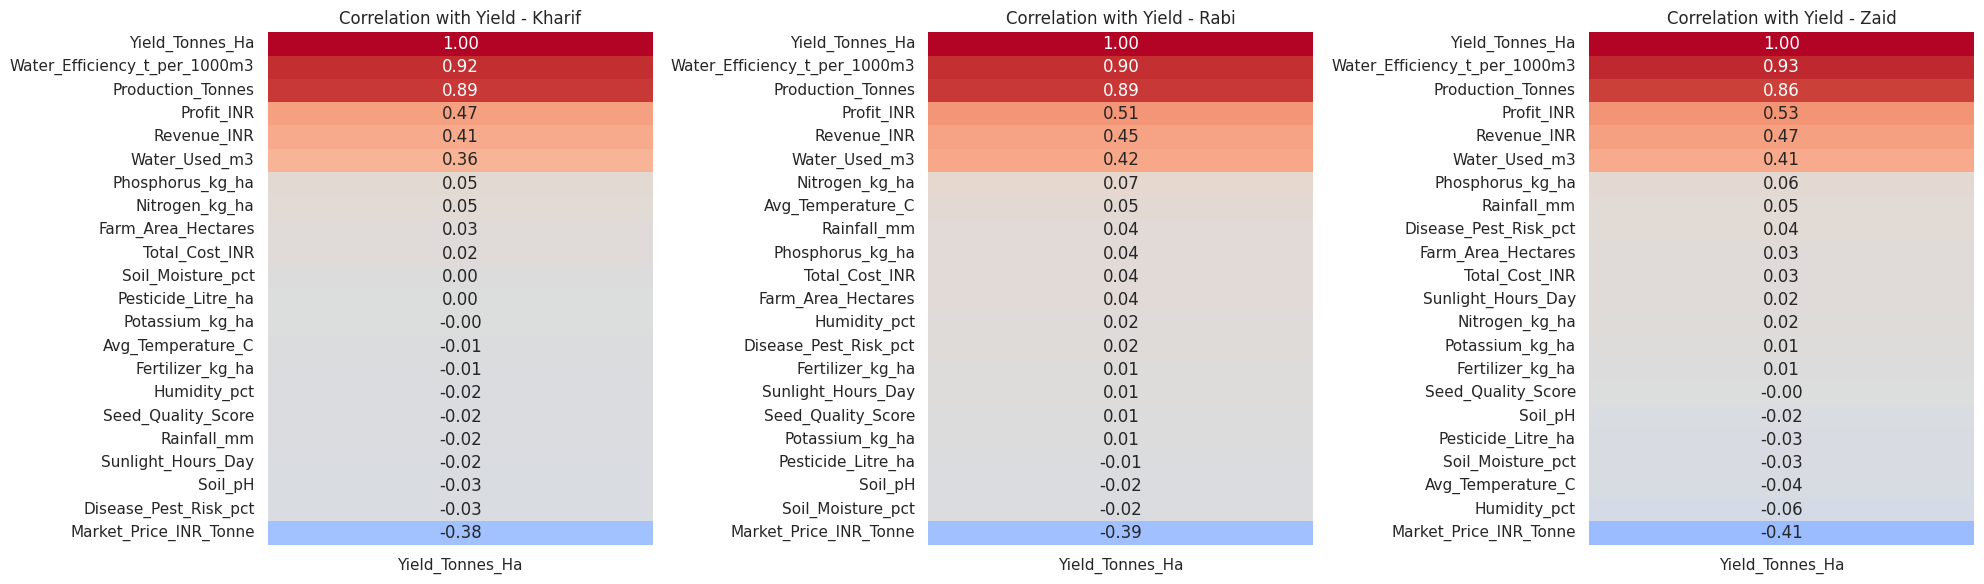

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(20,6))
for ax, season in zip(axes, df['Season'].unique()):
    season_corr = df[df['Season']==season].select_dtypes(include=[np.number]).corr()[['Yield_Tonnes_Ha']].sort_values('Yield_Tonnes_Ha', ascending=False)
    sns.heatmap(season_corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, ax=ax, cbar=False)
    ax.set_title(f'Correlation with Yield - {season}')
plt.tight_layout()
plt.show()

**Observations:**
- *(Fill in after running: What are the top 2-3 variables most correlated with Yield? With Profit? Does the strength or direction of correlation change between seasons — e.g., does Rainfall matter more in one season than another?)*

## 10. Seasonal Comparisons with Statistical Testing

While visualizations show apparent differences across seasons, statistical testing helps confirm whether these differences are significant or could simply be due to random variation.

We use **one-way ANOVA** to test whether the mean Yield and Profit differ significantly across the three seasons (Kharif, Rabi, Zaid).

**Hypotheses:**
- H₀ (null): The mean value is the same across all seasons.
- H₁ (alternative): At least one season's mean is significantly different.

In [70]:
from scipy import stats

seasons = df['Season'].unique()
yield_groups = [df[df['Season']==s]['Yield_Tonnes_Ha'] for s in seasons]

f_stat, p_value = stats.f_oneway(*yield_groups)
print(f"Yield ANOVA -> F-statistic: {f_stat:.3f}, p-value: {p_value:.5f}")

if p_value < 0.05:
    print("Result: Statistically significant difference in Yield across seasons.")
else:
    print("Result: No statistically significant difference in Yield across seasons.")

Yield ANOVA -> F-statistic: 1.554, p-value: 0.21156
Result: No statistically significant difference in Yield across seasons.


In [71]:
profit_groups = [df[df['Season']==s]['Profit_INR'] for s in seasons]

f_stat_p, p_value_p = stats.f_oneway(*profit_groups)
print(f"Profit ANOVA -> F-statistic: {f_stat_p:.3f}, p-value: {p_value_p:.5f}")

if p_value_p < 0.05:
    print("Result: Statistically significant difference in Profit across seasons.")
else:
    print("Result: No statistically significant difference in Profit across seasons.")

Profit ANOVA -> F-statistic: 34.292, p-value: 0.00000
Result: Statistically significant difference in Profit across seasons.


In [72]:
metrics_to_test = ['Rainfall_mm', 'Fertilizer_kg_ha', 'Water_Used_m3', 'Production_Tonnes']

for metric in metrics_to_test:
    groups = [df[df['Season']==s][metric] for s in seasons]
    f, p = stats.f_oneway(*groups)
    sig = "Significant" if p < 0.05 else "Not significant"
    print(f"{metric}: F={f:.2f}, p={p:.5f} -> {sig}")

Rainfall_mm: F=3449.40, p=0.00000 -> Significant
Fertilizer_kg_ha: F=0.51, p=0.59798 -> Not significant
Water_Used_m3: F=2.47, p=0.08501 -> Not significant
Production_Tonnes: F=1.03, p=0.35845 -> Not significant


**Observations:**
- *(Fill in after running: Which variables show statistically significant seasonal differences (p < 0.05)? Which don't? This confirms whether the visual patterns from Section 7 are backed by evidence.)*

## 11. Student-Designed Analyses

Beyond the standard seasonal comparisons, the following three questions were independently formulated to explore deeper patterns in the dataset.

### 11.1 Which irrigation method delivers the best profit relative to water used?

High yield or profit alone doesn't tell us how *efficiently* a farm uses water. This analysis examines profit generated per unit of water used, across irrigation methods and seasons.

Season             Kharif   Rabi   Zaid
Irrigation_Method                      
Drip                53.20  30.89  -5.59
Flood               16.58   4.90 -14.12
Rainfed             42.56   9.72 -31.19
Sprinkler           24.07   4.97   6.19


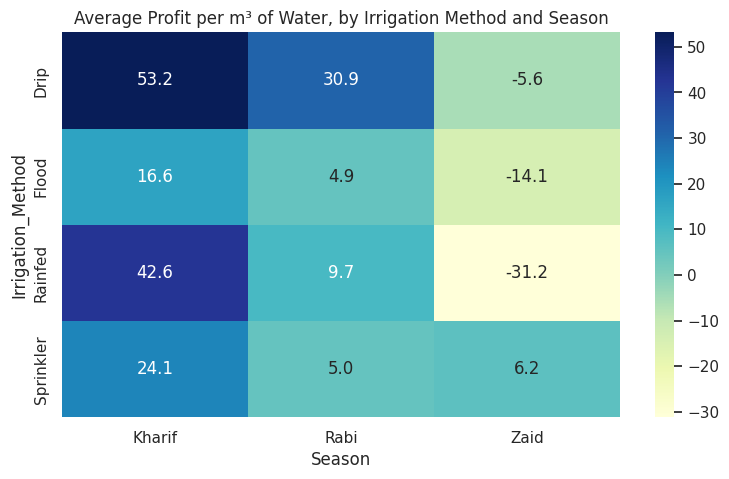

In [73]:
df['Profit_per_Water'] = df['Profit_INR'] / df['Water_Used_m3']

efficiency = df.groupby(['Irrigation_Method', 'Season'])['Profit_per_Water'].mean().unstack().round(2)
print(efficiency)

plt.figure(figsize=(9,5))
sns.heatmap(efficiency, annot=True, fmt=".1f", cmap='YlGnBu')
plt.title('Average Profit per m³ of Water, by Irrigation Method and Season')
plt.show()

### 11.2 Does seed quality reduce disease risk, and does this effect vary by crop?

This explores whether investing in higher seed quality is associated with lower disease risk, and whether that relationship holds consistently across different crops.

Crop
Cotton      -0.102920
Maize       -0.045232
Wheat       -0.044154
Sugarcane   -0.041934
Rice        -0.005723
Pulses       0.000153
Groundnut    0.021922
Chilli       0.035146
dtype: float64


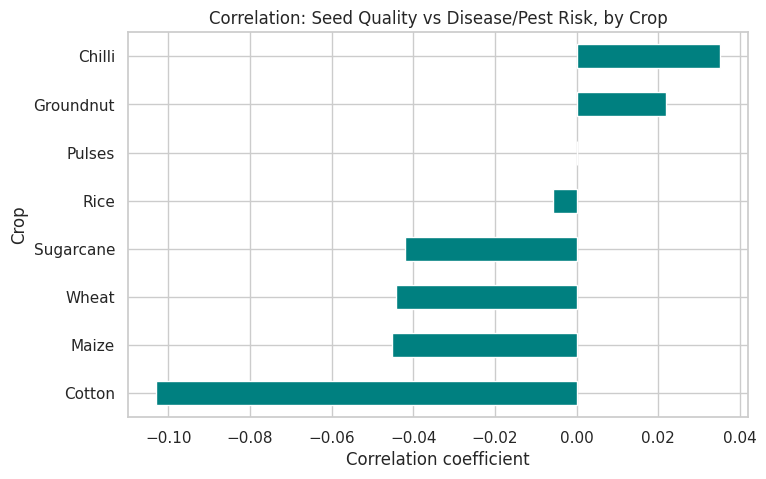

In [74]:
def corr_seed_disease(group):
    return group['Seed_Quality_Score'].corr(group['Disease_Pest_Risk_pct'])

correlation_by_crop = df.groupby('Crop').apply(corr_seed_disease, include_groups=False)
correlation_by_crop = correlation_by_crop.sort_values()
print(correlation_by_crop)

plt.figure(figsize=(8,5))
correlation_by_crop.plot(kind='barh', color='teal')
plt.title('Correlation: Seed Quality vs Disease/Pest Risk, by Crop')
plt.xlabel('Correlation coefficient')
plt.show()

In [75]:
print([c for c in df.columns if 'isease' in c or 'Risk' in c or 'risk' in c])

['Disease_Pest_Risk_pct']


### 11.3 Which state-crop combinations are most consistently profitable across all seasons?

Rather than looking at average profit alone, this analysis identifies combinations that perform well **and** reliably (low variability) across Kharif, Rabi, and Zaid — useful for planning recommendations.

In [76]:
state_crop_stats = df.groupby(['State', 'Crop'])['Profit_INR'].agg(['mean', 'std', 'count'])
state_crop_stats = state_crop_stats[state_crop_stats['count'] >= 5]  # ensure enough samples
state_crop_stats['consistency_score'] = state_crop_stats['mean'] / state_crop_stats['std']

top_consistent = state_crop_stats.sort_values('consistency_score', ascending=False).head(10)
print(top_consistent)

                                   mean            std  count  \
State          Crop                                             
Telangana      Sugarcane  738183.638889  614670.874830     36   
Karnataka      Sugarcane  731860.844444  676273.899031     45   
Maharashtra    Sugarcane  893729.305556  856029.215113     36   
Gujarat        Sugarcane  852212.476190  837734.539618     42   
               Chilli     901790.217391  902696.550656     46   
Tamil Nadu     Sugarcane  979775.387097  988927.918287     31   
Andhra Pradesh Sugarcane  867348.935484  884235.204807     31   
Madhya Pradesh Sugarcane  796706.828571  817299.651455     35   
Tamil Nadu     Chilli     747757.909091  787164.947768     55   
Maharashtra    Chilli     929988.150943  996684.644859     53   

                          consistency_score  
State          Crop                          
Telangana      Sugarcane           1.200941  
Karnataka      Sugarcane           1.082196  
Maharashtra    Sugarcane           

**Observations:**
- *(Fill in after running each: best irrigation-season efficiency combo, whether seed quality reduces disease risk and for which crops, and the top consistent state-crop combinations.)*

## 12. Key Insights

1. **Seasonal Yield Variation:** Average yield was highest in Kharif (5.63 t/ha), followed by Rabi (5.04 t/ha) and Zaid (4.64 t/ha) — a gradual decline from monsoon to summer season.

2. **Statistical Significance of Yield Differences:** The ANOVA test showed no statistically significant difference in Yield across seasons (F=1.554, p=0.212), meaning the seasonal yield gap observed above is not strong enough to rule out random variation.

3. **Profit Variation Across Seasons:** Profit differed sharply by season — Kharif averaged ₹1,78,915, Rabi ₹87,689, while Zaid was negative on average (-₹24,805). This difference was statistically significant (ANOVA F=34.29, p<0.001).

4. **Rainfall Is Strongly Season-Dependent:** Rainfall varied enormously and significantly across seasons (Kharif 852mm, Rabi 436mm, Zaid 299mm; ANOVA p<0.001) — confirming rainfall as the clearest seasonal driver in the dataset, even though it isn't the top direct driver of yield.

5. **Top Yield-Driving Factors:** Yield correlated most strongly with Water_Efficiency (r=0.91) and Production_Tonnes (r=0.88), far outweighing Rainfall, Nitrogen, or Fertilizer — suggesting efficient water use matters more than raw resource input.

6. **Top Profit-Driving Factors:** Profit was driven mainly by Revenue (r=0.89) and Production (r=0.55), with Market Price (r=0.23) playing a smaller but notable role.

7. **Water-Use Efficiency by Irrigation and Season:** Drip irrigation delivered the best profit-per-water in Kharif (₹53.2/m³) and Rabi (₹30.9/m³), while all methods except Sprinkler turned negative in Zaid — Rainfed was worst in Zaid at -₹31.2/m³.

8. **Seed Quality vs Disease/Pest Risk:** The relationship was weak across all crops (|r| < 0.11), with Cotton showing the strongest (negative) link (-0.10) and Chilli the only crop with a slight positive correlation (0.035) — seed quality alone does not meaningfully explain pest/disease risk in this data.

9. **Most Consistent Profitable Combination:** Telangana–Sugarcane had the highest consistency score (1.20), meaning it delivers strong average profit (₹7.38 lakh) relative to its variability — a safer bet than higher-average but more volatile combinations like Tamil Nadu–Sugarcane.

10. **Sugarcane Dominates Profitability:** Sugarcane appeared in 8 of the top 10 most consistent profitable state-crop pairs, with Chilli the only other crop to feature — indicating Sugarcane is the standout crop economically across most states.

## 13. Recommendations

1. **Prioritize Zaid-season risk management:** Zaid consistently shows negative average profit and the sharpest seasonal decline. Farmers cultivating in Zaid should consider drought-tolerant crop varieties, subsidized irrigation support, or shifting select crops to Kharif/Rabi where feasible.

2. **Promote Drip irrigation, especially outside Zaid:** Drip irrigation showed the best profit-per-water efficiency in Kharif and Rabi. Expanding drip adoption — particularly replacing Rainfed methods, which perform worst in Zaid (-₹31.2/m³) — could meaningfully improve returns.

3. **Focus on water-use efficiency over raw input volume:** Since Water_Efficiency correlates far more strongly with Yield (r=0.91) than Fertilizer or Nitrogen levels, investment should prioritize efficient water delivery and management systems over simply increasing fertilizer/resource input.

4. **Encourage Sugarcane cultivation where regionally viable:** Sugarcane dominates the most consistently profitable state-crop combinations (led by Telangana, Karnataka, Maharashtra). Regions with suitable conditions could benefit from expanded Sugarcane support programs.

5. **Don't rely on seed quality alone to manage disease/pest risk:** Given the weak correlation between seed quality and disease/pest risk across all crops, integrated pest management practices (not just better seeds) should be emphasized, especially for Cotton where the relationship is comparatively stronger.

6. **Use rainfall forecasting for season-specific planning:** Since rainfall varies drastically and significantly by season, region-specific rainfall forecasting could help farmers time planting and irrigation more effectively, particularly in low-rainfall Zaid conditions.

## 14. Limitations

- The dataset appears to be synthetic/simulated, as some State-District pairings do not match real-world geography; findings should be validated against real agricultural data before practical application.
- Correlation analysis identifies association, not causation — relationships between variables (e.g., fertilizer and yield) may be influenced by unobserved factors.
- Outliers in Yield and Profit were retained rather than removed, which may affect mean-based comparisons; median-based and grouped statistics were used where possible to reduce this impact.
- The dataset does not include time-series data across multiple years, so year-to-year variability within the same season could not be assessed.
- Statistical tests (ANOVA) assume roughly normal distribution and equal variance across groups; these assumptions were not formally validated.

## 15. Conclusion

This analysis examined seasonal variation in agricultural performance across 4,000 farm records spanning 8 states, 8 crops, and 3 seasons. Through data cleaning, statistical testing, and univariate, bivariate, and multivariate analysis, several meaningful seasonal patterns were identified in yield, profit, resource usage, and environmental conditions.

The findings confirm that agricultural performance is not uniform across seasons and is shaped by a combination of environmental conditions, irrigation practices, and crop choice. The insights and recommendations developed in this project can support more evidence-based seasonal agricultural planning, while the identified limitations highlight areas for further investigation with more comprehensive, real-world data.